# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Chapter 27: Pretraining**

## **Section 1: 学習前の設定**

ファイナルステージ！

FinewebデータセットとG4 GPUを使って学習します。

| 項目     | 内容            |
| ------ | ------------- |
| データセット | Fineweb       |
| モデルサイズ | 0.5B          |
| 実行環境   | Colab（G4 GPU） |
| 学習時間   | 約20時間         |

必要な課金（約20ドル）

* Colab Pro（約10ドル）※⚠️ 月額課金のため不要なら解約
* 追加コンピューティングユニット（約10ドル）



**`Check Point`** <label><input type="checkbox">G4 GPUに接続したことを確認した<label>

Finewebデータセットをダウンロードします。これには約3~5分かかります。

In [1]:
from huggingface_hub import hf_hub_download
hf_hub_download(
    repo_id="HayatoHongo/fineweb-edu-100b-shuffle",
    repo_type="dataset",
    filename="edufineweb_train.npy",
    local_dir=".",
)

edufineweb_train.npy:   0%|          | 0.00/19.7G [00:00<?, ?B/s]

'edufineweb_train.npy'

Configクラスは、以下のように設定します。

**一番設定が面倒なのは：学習率（Learning Rate）**

学習率が難しい理由（最小限）：
- モデルが大きいほど、学習率を小さくしないと不安定になりやすい
- ただしバッチサイズが大きいと、学習率が多少大きくても大丈夫な場合がある
- 学習率スケジューラがあるので、少し大きめでも吸収できる場合がある
- **最適値に対して、1ケタ大きいだけで学習が不安定で破綻☠️、1ケタ小さければ学習が遅すぎて破綻☠️**

結局、最適な学習率はよくわからないので本来は試行錯誤で探します。    
ただし計算コストが高くお金もかかるため、今回はそのプロセスを省略します。

今回は私の試行錯誤の結果として、最大学習率として **`2e-4` が多分いい感じ**と把握しています。

In [ ]:
class Config:
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_training_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280 # 384
    hidden_dim: int = 5120 # 1536
    num_attention_heads: int = 10 # 6
    layer_count: int = 20 # 12
    num_relative_positions = 1024 # 128

    # === optimization ===
    max_learning_rate: float = 2e-4 # 1e-3
    min_learning_rate: float = 2e-5 # 1e-4
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"
    """DELETE
    random_seed_value: int = 1337
    """

Configクラスのインスタンスを作成します。

In [3]:
config = Config()

Dataloaderクラスについて、変更はありません。

In [4]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）
        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

    def get_batch(self):

        # ランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。
        # データ全体を対象にランダムに開始位置を選ぶ
        range_start, range_end = 0, len(self.data)

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

データローダーのインスタンスを作成します。

In [5]:
data_loader = DataLoader("edufineweb_train.npy", config)

モデルクラスについて、DropOutを無効化します。

Attentionの頃からの初期メンツで、過学習を避けるために導入されていました。

ただ、データ量が圧倒的に多いので、過学習のリスクは低いです。

しかもDropOut、計算量を少し増やしちゃいます。ぶっちゃけ本当に不要です。

初期メンツとはいえ役に立たないという、ワンピースのウソップ的立場なのでリストラします。

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # 相対距離を範囲 [0, max_distance - 1] に収める（負の距離や過大距離を切り詰め）
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # 埋め込み層から対応するバイアスベクトルを取得
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # 最後の次元を除去して行列化
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        """DELETE
        self.dropout = nn.Dropout(config.dropout_rate)
        """
        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        """DELETE
        attention_weights = self.dropout(attention_weights)
        """

        out = attention_weights @ Value  # (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        """DELETE
        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        """

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        """DELETE
        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output
        """

        ########## NEW ##########
        return projected
        ########## NEW ##########

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            # """DELETE nn.Dropout(config.dropout_rate),"""
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


パラメータ数が0.5Bなので、もはやnanoGPTという名前は似合いませんね。

ついに、モデルクラスにあなたの名前をつける時がきました。（例：OliviasGPT）

⚠️ 穴埋め部分あり。モデルクラスを命名してください。

In [7]:
class _______sGPT(nn.Module): # TODO: FILL
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

⚠️ 穴埋め部分あり。モデルクラスを命名してください。

In [8]:
# model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
model = _______sGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type) # TODO: FILL

学習率スケジュールについて、特に変更はありません。

In [9]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_training_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


チェックポイント関連について、特に変更はありません。

In [10]:
import os

def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")


def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_data["model_state_dict"])
    optimizer.load_state_dict(checkpoint_data["optimizer_state_dict"])

    print(f"[INFO] Resume completed at step {step}")

Trainerクラスの`train_step`メソッドに対して、bf16によるautocastという高速化を使います。

詳細は割愛させて頂きますが🙇‍♂️、これで学習が2倍以上速くなります。

In [11]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, start_step=0):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir
        self.start_step = start_step

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        ########## NEW ##########
        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):
        ########## NEW ##########
            logits, loss = self.model(input_batch, target_batch)

        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

## **Section 2: HuggingFace連携**

モデル学習は20時間に渡ります。

その間、間違ってパソコンを閉じてしまうかもしれません。移動して通信が切れてしまうかもしれません。

クレジットを無駄にしないために、チェックポイントを逐一、HuggingFaceにアップロードしましょう。

まずはhuggingface_hubにログインしてください。手順は下にあります。

In [12]:
from huggingface_hub import login
login()

以前取得した、アクセストークンを貼り付けてください！

アクセストークンなくしました！😎 <br>
-> 1. スクワット100回<br>
-> 2. https://huggingface.co/settings/tokens にアクセス<br>
-> 3. アクセストークンを再発行する。<br>

[Watch the video!](https://youtu.be/LuqQUi7Y47I)
- 45 seconds, no-sound
- Video ID: LuqQUi7Y47I

チェックポイントディレクトリをアップロードする先として、HuggingFaceリポジトリを作成します。

⚠️ 穴埋め部分あり。HuggingFaceのアカウント名を記入してください。

In [13]:
from huggingface_hub import create_repo

repo_id = "HayatoHongo/EveryonesGPT-checkpoints" # TODO: FILL example: "HayatoHongo/EveryonesGPT-checkpoints"
create_repo(repo_id=repo_id, private=False, exist_ok=True)

RepoUrl('https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints', endpoint='https://huggingface.co', repo_type='model', repo_id='HayatoHongo/EveryonesGPT-checkpoints')

Colab → Hugging FaceHub へのフォルダアップロードが動くか、最小構成でテストします。

**手順（これだけ）**
1. チェックポイント用フォルダを作る（`./checkpoints`）
2. 中に空ファイル `empty_checkpoint.pt` を1つ作る
3. そのファイルを `upload_file(...)` でアップロードする
4. Hugging Face のブラウザで、リポジトリ内に `empty_checkpoint.pt が見えるか確認する


1. チェックポイント用フォルダを作る（`./checkpoints`）

In [14]:
import os
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

2. 中に空ファイル `empty_checkpoint.pt` を1つ作る

In [15]:
checkpoint_filename = "empty_checkpoint.pt"
checkpoint_path = os.path.join(checkpoint_dir, checkpoint_filename)
print("checkpoint_path\n", checkpoint_path)

checkpoint_path
 ./checkpoints/empty_checkpoint.pt


3. そのファイルを `upload_file(...)` でアップロードする

In [16]:
# Create an empty file
with open(checkpoint_path, "a", encoding="utf-8"):
    pass

4. Hugging Face のブラウザで、リポジトリ内に `empty_checkpoint.pt が見えるか確認する

In [17]:
from huggingface_hub import upload_file

upload_file(path_or_fileobj=checkpoint_path, path_in_repo=checkpoint_path, repo_id=repo_id)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints/commit/e00bbf2c5bb8dec54951ad7e1b4f6a58cc753594', commit_message='Upload ./checkpoints/empty_checkpoint.pt with huggingface_hub', commit_description='', oid='e00bbf2c5bb8dec54951ad7e1b4f6a58cc753594', pr_url=None, repo_url=RepoUrl('https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints', endpoint='https://huggingface.co', repo_type='model', repo_id='HayatoHongo/EveryonesGPT-checkpoints'), pr_revision=None, pr_num=None)

HFリポジトリにチェックポイントディレクトリがアップロードされたかを確認します。

Chromeなどのブラウザで、以下のリンクにアクセスします。  
YOURNAMEを、あなたのアカウント名に置き換えてください。  
リンク： https://huggingface.co/YOURNAME/EveryonesGPT-checkpoints/tree/main

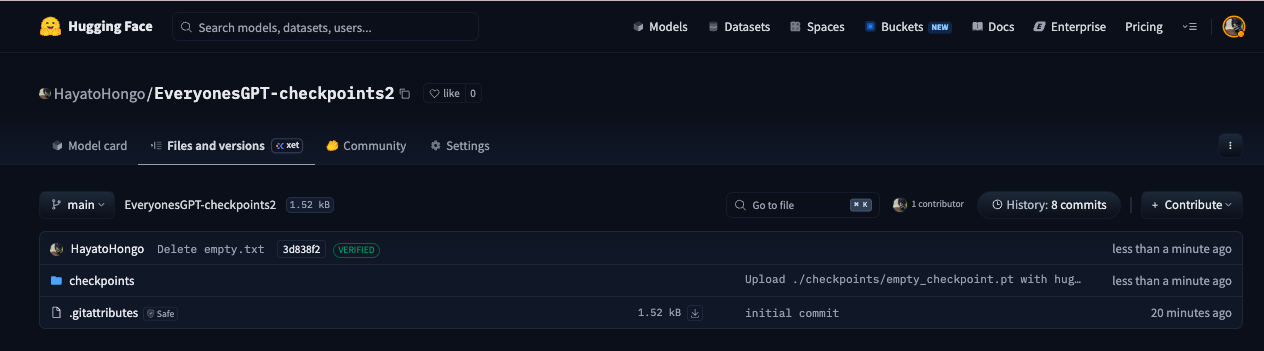

`checkpoints`ディレクトリをクリックして中身を見ると、`empty_checkpoint.pt`ファイルがあります。


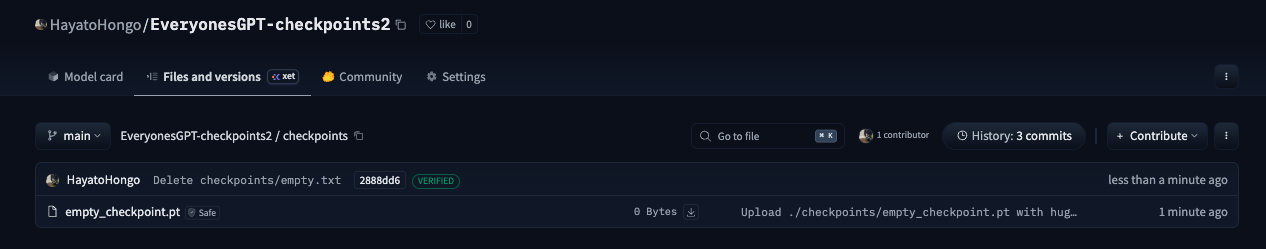

**`Check Point`** <label><input type="checkbox">empty_checkpoint.ptがアップロードされていることを確認した<label>

Colab側のcheckpointsをHuggingFaceにアップロードすることができました。

それでは、Colab側のチェックポイントディレクトリをあえて削除します。

そして、HuggingFaceからチェックポイントファイルを復元できるか試しましょう。

In [18]:
!rm -rf checkpoints

HuggingFaceから、チェックポイントファイルをダウンロードします。


In [19]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id=repo_id, filename=checkpoint_path, local_dir=".")

'checkpoints/empty_checkpoint.pt'

**`Check Point`** <label><input type="checkbox">empty_checkpoint.ptがダウンロードされていることを確認した<label>

これをTrainerクラスに組み込みます。穴埋めはありません。

In [20]:
import time
########## NEW ##########
from huggingface_hub import hf_hub_download
from huggingface_hub import create_repo
from huggingface_hub import upload_file
########## NEW ##########

class Trainer:
    """DELETE
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, start_step=0):
    """
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, repo_id, start_step=0):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir
        ########## NEW ##########
        self.repo_id = repo_id
        ########## NEW ##########
        self.start_step = start_step

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        ########## NEW ##########
        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):
        ########## NEW ##########
            logits, loss = self.model(input_batch, target_batch)

        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        if self.start_step > 0:
            ########## NEW ##########
            checkpoint_filename = f"checkpoint_{self.start_step:06d}.pt"
            checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
            hf_hub_download(repo_id=self.repo_id, filename=checkpoint_path, local_dir=".")
            ########## NEW ##########
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)


        total_train_time = 0
        last_log_time = time.time()

        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.start_step+1, self.config.total_training_steps+1):
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)
                ########## NEW ##########
                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                checkpoint_filename = f"checkpoint_{step:06d}.pt"
                checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
                upload_file(repo_id=self.repo_id, path_or_fileobj=checkpoint_path, path_in_repo=checkpoint_path)
                ########## NEW ##########

            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

## **Section 3: モデル学習**

torch compile という高速化手法を用います。こちらも詳細は割愛させてください🙇‍♂️

なお、このセルを2回以上実行してはいけません。


In [21]:
# ⚠️ Don't run this cell twice!
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)

オプティマイザを設定します。`fused=True`という高速化手法を使います。

こちらも詳細は割愛させてください😭

In [22]:
# close to nanoGPT setting
optimizer = torch.optim.AdamW(
    compiled_model.parameters(),
    betas=(0.9, 0.95),
    weight_decay=0.1,
    ########## NEW ##########
    fused=True,
    ########## NEW ##########
)

Trainerクラスのインスタンスを作成します。

⚠️ 穴埋め部分あり。HuggingFaceのアカウント名を記入してください。

In [27]:
trainer = Trainer(
    model=compiled_model,
    optimizer=optimizer,
    data_loader=data_loader,
    config=config,
    checkpoint_dir="./checkpoints",
    repo_id = "HayatoHongo/EveryonesGPT-checkpoints",  # TODO: FILL example: "HayatoHongo/EveryonesGPT-checkpoints"
    start_step=0,
)

モデルインスタンス`compiled_model`を、学習モードに設定します。

In [28]:
compiled_model.train()

OptimizedModule(
  (_orig_mod): _______sGPT(
    (token_embedding_layer): TokenEmbedding(
      (token_embedding_table): Embedding(50257, 1280)
    )
    (blocks): Sequential(
      (0): TransformerBlock(
        (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (multihead_attention): MultiHeadAttention(
          (attention_heads): ModuleList(
            (0-9): 10 x AttentionHead(
              (key_fc): Linear(in_features=1280, out_features=128, bias=False)
              (query_fc): Linear(in_features=1280, out_features=128, bias=False)
              (value_fc): Linear(in_features=1280, out_features=128, bias=False)
              (relative_position_embedding_layer): RelativePositionEmbedding(
                (bias_embedding_table): Embedding(1024, 1)
              )
            )
          )
          (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
  

それではモデルを訓練しましょう。

訓練は約20時間です。パソコンを閉じないこと、移動して通信を切らさないことに気をつけてください。

もし、途中でセッションが切れてしまっても大丈夫です。



HuggingFace上で保存したチェックポイントから再開します。

start_stepを再開したいステップ数に設定して、Trainerクラスのインスタンスを作成します。

In [29]:
trainer.train()

# 学習が完了したら推論もやってみる
compiled_model.eval()
prompt = "AI is"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = compiled_model.generate(encoded_tensor, max_new_tokens=256, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

step 00001 |  lr 2.000000e-07 |  train loss 5.8406 |  tok/s 46214 |  tokens 32,768 |  time 0.71s
step 00002 |  lr 4.000000e-07 |  train loss 5.7127 |  tok/s 46306 |  tokens 65,536 |  time 1.42s
step 00003 |  lr 6.000000e-07 |  train loss 5.6677 |  tok/s 46301 |  tokens 98,304 |  time 2.12s
step 00004 |  lr 8.000000e-07 |  train loss 5.7855 |  tok/s 46296 |  tokens 131,072 |  time 2.83s
step 00005 |  lr 1.000000e-06 |  train loss 5.6523 |  tok/s 46325 |  tokens 163,840 |  time 3.54s
step 00006 |  lr 1.200000e-06 |  train loss 5.7074 |  tok/s 46328 |  tokens 196,608 |  time 4.25s
step 00007 |  lr 1.400000e-06 |  train loss 5.6565 |  tok/s 46328 |  tokens 229,376 |  time 4.95s
step 00008 |  lr 1.600000e-06 |  train loss 5.7786 |  tok/s 46305 |  tokens 262,144 |  time 5.66s
step 00009 |  lr 1.800000e-06 |  train loss 5.6620 |  tok/s 46288 |  tokens 294,912 |  time 6.37s
step 00010 |  lr 2.000000e-06 |  train loss 5.6238 |  tok/s 46300 |  tokens 327,680 |  time 7.08s
step 00011 |  lr 2.2000

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 27: Pretraining** <label><input type="checkbox"> Mark as Done</label>